<a href="https://colab.research.google.com/github/koh-hongQ/Understanding_AI_with_Math/blob/main/%ED%95%B8%EC%A6%88%EC%98%A8%20LLM%205%EC%9E%A5%20%EC%BD%94%EB%93%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 202200307 ***고홍규***

# ArXiv

In [ ]:
# Load data from huggingface
from datasets import load_dataset
dataset = load_dataset("maartengr/arxiv_nlp")["train"]

# Extract metadata
abstracts = dataset["Abstracts"]
titles = dataset["Titles"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/617 [00:00<?, ?B/s]

data.csv:   0%|          | 0.00/53.2M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

# **A Common Pipeline for Text Clustering**

## **1. Embedding Documents**

In [ ]:
from sentence_transformers import SentenceTransformer

# Create an embedding for each abstract
embedding_model = SentenceTransformer('thenlper/gte-small')
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)

modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/66.7M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

In [ ]:
# Check the dimensions of the resulting embeddings
embeddings.shape

(44949, 384)

## **2. Reducing the Dimensionality of Embeddings**

In [ ]:
from umap import UMAP

# We reduce the input embeddings from 384 dimenions to 5 dimenions
umap_model = UMAP(
    n_components=5, min_dist=0.0, metric='cosine', random_state=42
)
reduced_embeddings = umap_model.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## **3. Cluster the Reduced Embeddings**

In [ ]:
from hdbscan import HDBSCAN

# We fit the model and extract the clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=50, metric='euclidean', cluster_selection_method='eom'
).fit(reduced_embeddings)
clusters = hdbscan_model.labels_

# How many clusters did we generate?
len(set(clusters))

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


150

## **Inspecting the Clusters**

In [ ]:
import numpy as np

# Print first three documents in cluster 0
cluster = 0
for index in np.where(clusters == cluster)[0][:3]:
    i = int(index)  # numpy.int64 → int
    print(abstracts[i][:300] + "... \n")

  This works aims to design a statistical machine translation from English text
to American Sign Language (ASL). The system is based on Moses tool with some
modifications and the results are synthesized through a 3D avatar for
interpretation. First, we translate the input text to gloss, a written fo... 

  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonological and phonetic aspects, and gesture studies for
recognition and synthesis purposes. This paper focuses on the imbrication of
motion and meaning for the analysis, synthesis and evaluation of sign lang... 

  Modern computational linguistic software cannot produce important aspects of
sign language translation. Using some researches we deduce that the majority of
automatic sign language translation systems ignore many aspects when they
generate animation; therefore the interpretation lost the truth inf... 



In [ ]:
import pandas as pd

# Reduce 384-dimensional embeddings to 2 dimensions for easier visualization
reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric='cosine', random_state=42
).fit_transform(embeddings)

# Create dataframe
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]

# Select outliers and non-outliers (clusters)
clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Static Plot

(np.float64(-7.676335239410401),
 np.float64(10.47340669631958),
 np.float64(-1.642096960544586),
 np.float64(18.73199769258499))

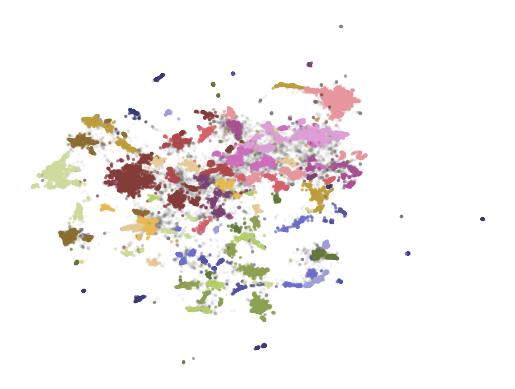

In [ ]:
import matplotlib.pyplot as plt

# Plot outliers and non-outliers seperately
plt.scatter(outliers_df.x, outliers_df.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    clusters_df.x, clusters_df.y, c=clusters_df.cluster.astype(int),
    alpha=0.6, s=2, cmap='tab20b'
)
plt.axis('off')
# plt.savefig("matplotlib.png", dpi=300)  # Uncomment to save the graph as a .png

# From Text Clustering to Topic Modeling

## **BERTopic: A Modular Topic Modeling Framework**

In [ ]:
!pip install bertopic[all]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 10.2 MB/s eta 0:00:00


In [ ]:
from bertopic import BERTopic

# Train our model with our previously defined models
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(abstracts, embeddings)

2025-11-12 13:38:49,932 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-12 13:39:45,052 - BERTopic - Dimensionality - Completed ✓
2025-11-12 13:39:45,054 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-12 13:39:47,744 - BERTopic - Cluster - Completed ✓
2025-11-12 13:39:47,757 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-12 13:39:51,864 - BERTopic - Representation - Completed ✓


In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,14168,-1_Science/Tech___,"[Science/Tech, , , , , , , , , ]",[ Recent work on speech representation models...
1,0,2173,0_Question Generation___,"[Question Generation, , , , , , , , , ]",[ While models have reached superhuman perfor...
2,1,2074,1_Speech-to-speech___,"[Speech-to-speech, , , , , , , , , ]",[ We introduce the Universal Speech Model (US...
3,2,1532,2_Science/Tech___,"[Science/Tech, , , , , , , , , ]",[ Distributed representations of medical conc...
4,3,903,3_Science/Tech___,"[Science/Tech, , , , , , , , , ]","[ In this paper, we introduce a hybrid search..."
...,...,...,...,...,...
145,144,56,144_Psychiatric___,"[Psychiatric, , , , , , , , , ]",[ Mental health care poses an increasingly se...
146,145,54,145_emoji semantics___,"[emoji semantics, , , , , , , , , ]","[ There is a new generation of emoticons, cal..."
147,146,53,146_Coherence___,"[Coherence, , , , , , , , , ]",[ While there has been significant progress t...
148,147,52,147_generative adversarial networks___,"[generative adversarial networks, , , , , , , ...",[ Text generation is of particular interest i...


In [ ]:
topic_model.get_topic(0)

[('Question Generation', 1),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0)]

In [ ]:
topic_model.find_topics("topic modeling")

([25, -1, 2, 28, 41],
 [np.float32(0.954654),
  np.float32(0.91121185),
  np.float32(0.9086579),
  np.float32(0.9084902),
  np.float32(0.9040556)])

In [ ]:
topic_model.get_topic(22)

[('explanations', np.float64(0.04598007260081089)),
 ('explanation', np.float64(0.02613316825664155)),
 ('interpretability', np.float64(0.010366878638629676)),
 ('predictions', np.float64(0.010321983905983855)),
 ('explainability', np.float64(0.009513975593333491)),
 ('methods', np.float64(0.009314330833586027)),
 ('faithfulness', np.float64(0.00847742100886137)),
 ('saliency', np.float64(0.007798205936803249)),
 ('attribution', np.float64(0.007651971118724982)),
 ('nlp', np.float64(0.0075629350832661525))]

In [ ]:
topic_model.topics_[titles.index('BERTopic: Neural topic modeling with a class-based TF-IDF procedure')]

25

### **Visualizations**

**Visualize Documents**

In [ ]:
titles = list(titles)
reduced_embeddings = np.array(reduced_embeddings)

fig = topic_model.visualize_documents(
    titles,
    reduced_embeddings=reduced_embeddings,
    width=1200,
    hide_annotations=True
)

fig.update_layout(font=dict(size=16))
fig.show()


In [ ]:
# Visualize barchart with ranked keywords
topic_model.visualize_barchart()

# Visualize relationships between topics
topic_model.visualize_heatmap(n_clusters=30)

# Visualize the potential hierarchical structure of topics
topic_model.visualize_hierarchy()

## **Representation Models**


```python
from bertopic.representation import KeyBERTInspired
from bertopic import BERTopic

# Create your representation model
representation_model = KeyBERTInspired()

# Use the representation model in BERTopic on top of the default pipeline
topic_model = BERTopic(representation_model=representation_model)
```

In [ ]:
# Save original representations
from copy import deepcopy
original_topics = deepcopy(topic_model.topic_representations_)

In [ ]:
def topic_differences(model, original_topics, nr_topics=5):
    """Show the differences in topic representations between two models """
    df = pd.DataFrame(columns=["Topic", "Original", "Updated"])
    for topic in range(nr_topics):

        # Extract top 5 words per topic per model
        og_words = " | ".join(list(zip(*original_topics[topic]))[0][:5])
        new_words = " | ".join(list(zip(*model.get_topic(topic)))[0][:5])
        df.loc[len(df)] = [topic, og_words, new_words]

    return df

### KeyBERTInspired

In [ ]:
from bertopic.representation import KeyBERTInspired

# Update our topic representations using KeyBERTInspired
representation_model = KeyBERTInspired()
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,question | qa | answer | questions | answering,questions | comprehension | answering | qa | q...
1,1,speech | asr | recognition | end | acoustic,phonetic | speech | language | voice | encoder
2,2,medical | clinical | biomedical | patient | he...,ehr | nlp | medicine | clinical | text
3,3,translation | nmt | machine | neural | bleu,translation | translate | translations | multi...
4,4,hate | offensive | speech | detection | toxic,hate | hateful | language | languages | offensive


### Maximal Marginal Relevance

In [ ]:
from bertopic.representation import MaximalMarginalRelevance

# Update our topic representations to MaximalMarginalRelevance
representation_model = MaximalMarginalRelevance(diversity=0.5)
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,question | qa | answer | questions | answering,questions | retrieval | comprehension | knowle...
1,1,speech | asr | recognition | end | acoustic,speech | asr | error | model | automatic
2,2,medical | clinical | biomedical | patient | he...,clinical | biomedical | patient | healthcare |...
3,3,translation | nmt | machine | neural | bleu,translation | nmt | neural | bleu | parallel
4,4,hate | offensive | speech | detection | toxic,offensive | toxic | social | hateful | platforms


## Text Generation



### Flan-T5

In [ ]:
from transformers import pipeline
from bertopic.representation import TextGeneration

prompt = """I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: '[KEYWORDS]'.

Based on the documents and keywords, what is this topic about?"""

# Update our topic representations using Flan-T5
generator = pipeline('text2text-generation', model='google/flan-t5-small')
representation_model = TextGeneration(
    generator, prompt=prompt, doc_length=50, tokenizer="whitespace"
)
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0
100%|██████████| 150/150 [00:49<00:00,  3.05it/s]


,Topic,Original,Updated
0,0,question | qa | answer | questions | answering,Question Generation | | | |
1,1,speech | asr | recognition | end | acoustic,Speech-to-speech | | | |
2,2,medical | clinical | biomedical | patient | he...,Science/Tech | | | |
3,3,translation | nmt | machine | neural | bleu,Science/Tech | | | |
4,4,hate | offensive | speech | detection | toxic,Science/Tech | | | |


In [ ]:
import openai
from bertopic.representation import OpenAI

prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: [KEYWORDS]

Based on the information above, extract a short topic label in the following format:
topic: <short topic label>
"""

# Update our topic representations using GPT-3.5
client = openai.OpenAI(api_key="제 키를 입력하여 실행했습니다. 이후 보안으로 인해 이렇게 제 키를 지웠습니다.")
representation_model = OpenAI(
    client, model="gpt-3.5-tur`bo", exponential_backoff=True, chat=True, prompt=prompt
)
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

100%|██████████| 150/150 [02:00<00:00,  1.24it/s]


,Topic,Original,Updated
0,0,question | qa | answer | questions | answering,Question Answering Models and Evaluation Methods
1,1,speech | asr | recognition | end | acoustic,Advances in End-to-End Speech Recognition Systems
2,2,medical | clinical | biomedical | patient | he...,Advancements in Medical Text Processing and He...
3,3,translation | nmt | machine | neural | bleu,Neural Machine Translation Optimization and En...
4,4,hate | offensive | speech | detection | toxic,Multilingual Hate Speech Detection and Classif...
